**Step 1: Understanding the Problem Statement**

**Banking Domain**





Build a machine learning model to predict whether a customer will default on a loan based on financial and demographic details.The target variable is Loan_Default, which is binary (0 = No, 1 = Yes).


**Step 2: Import libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

 **Step 3: Dataset Generation**

A synthetic dataset was created with 5000 rows and 20 columns. The dataset includes features such as income, credit score, employment status, loan amount, and previous defaults.

The dataset was designed with:

Missing values,
Noise in numerical columns,
Outliers,
Logical relationships between variables



In [2]:


np.random.seed(42)

n = 5000

data = pd.DataFrame({
    "Age": np.random.randint(21, 65, n),
    "Income": np.random.randint(20000, 200000, n),
    "Loan_Amount": np.random.randint(5000, 100000, n),
    "Credit_Score": np.random.randint(300, 850, n),
    "Employment_Status": np.random.choice(["Employed", "Unemployed", "Self-Employed"], n),
    "Loan_Term": np.random.choice([12, 24, 36, 60, 120], n),
    "Previous_Defaults": np.random.randint(0, 4, n),
    "Marital_Status": np.random.choice(["Single", "Married", "Divorced"], n),
    "Dependents": np.random.randint(0, 5, n),
    "Education_Level": np.random.choice(["High School", "Bachelors", "Masters", "PhD"], n),
    "Property_Area": np.random.choice(["Urban", "Semi-Urban", "Rural"], n),
    "Savings": np.random.randint(0, 100000, n),
    "Credit_Card_Usage": np.random.randint(0, 100, n),
    "Loan_Purpose": np.random.choice(["Home", "Car", "Education", "Business"], n),
    "Employment_Years": np.random.randint(0, 40, n),
    "Debt_to_Income": np.random.uniform(0.1, 0.9, n),
    "Bank_Balance": np.random.randint(0, 200000, n),
    "Late_Payments": np.random.randint(0, 10, n),
    "Region": np.random.choice(["North", "South", "East", "West"], n)
})

# Target variable logic
data["Loan_Default"] = (
    (data["Credit_Score"] < 500) |
    (data["Income"] < 40000) |
    (data["Previous_Defaults"] > 1) |
    (data["Debt_to_Income"] > 0.6)
).astype(int)

# Add noise
data["Income"] += np.random.randint(-10000, 10000, n)

# Add missing values
for col in ["Income", "Credit_Score", "Savings"]:
    data.loc[data.sample(frac=0.1).index, col] = np.nan

# Add outliers
data.loc[data.sample(frac=0.02).index, "Income"] *= 3

# Save dataset
data.to_csv("loan_default_5000.csv", index=False)

data.head()



,Age,Income,Loan_Amount,Credit_Score,Employment_Status,Loan_Term,Previous_Defaults,Marital_Status,Dependents,Education_Level,Property_Area,Savings,Credit_Card_Usage,Loan_Purpose,Employment_Years,Debt_to_Income,Bank_Balance,Late_Payments,Region,Loan_Default
0,59,38200.0,56248,381.0,Unemployed,12,2,Single,0,High School,Urban,45579.0,93,Home,1,0.666524,45575,2,North,1
1,49,NaN,88602,492.0,Self-Employed,24,3,Married,4,Bachelors,Urban,56847.0,23,Home,39,0.730618,118187,6,North,1
2,35,27523.0,50371,488.0,Self-Employed,36,3,Single,0,Masters,Semi-Urban,NaN,30,Education,13,0.544529,27037,1,North,1
3,63,184860.0,72996,575.0,Unemployed,12,1,Married,4,Bachelors,Urban,51316.0,77,Business,11,0.624947,5383,3,South,1
4,28,NaN,42297,373.0,Self-Employed,120,1,Divorced,3,High School,Rural,87188.0,79,Car,23,0.748994,115513,3,West,1


**Step 4: Loading the Dataset**

In [3]:
df = pd.read_csv("loan_default_5000.csv")


**STEP 5: EDA**

Basic checks were performed

In [4]:
df.shape

(5000, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                5000 non-null   int64  
 1   Income             4500 non-null   float64
 2   Loan_Amount        5000 non-null   int64  
 3   Credit_Score       4500 non-null   float64
 4   Employment_Status  5000 non-null   object 
 5   Loan_Term          5000 non-null   int64  
 6   Previous_Defaults  5000 non-null   int64  
 7   Marital_Status     5000 non-null   object 
 8   Dependents         5000 non-null   int64  
 9   Education_Level    5000 non-null   object 
 10  Property_Area      5000 non-null   object 
 11  Savings            4500 non-null   float64
 12  Credit_Card_Usage  5000 non-null   int64  
 13  Loan_Purpose       5000 non-null   object 
 14  Employment_Years   5000 non-null   int64  
 15  Debt_to_Income     5000 non-null   float64
 16  Bank_Balance       5000 

In [6]:
df.describe()

,Age,Income,Loan_Amount,Credit_Score,Loan_Term,Previous_Defaults,Dependents,Savings,Credit_Card_Usage,Employment_Years,Debt_to_Income,Bank_Balance,Late_Payments,Loan_Default
count,5000.000000,4500.000000,5000.000000,4500.000000,5000.000000,5000.000000,5000.00000,4500.000000,5000.00000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,42.575000,114514.511556,52453.456200,573.163556,52.341600,1.491800,1.99620,50204.748000,49.33740,19.691600,0.502041,97438.12180,4.597000,0.815200
std,12.554597,64010.652712,27725.390159,157.906124,39.085056,1.118831,1.40861,28695.018508,29.01334,11.462197,0.230936,58223.23051,2.881432,0.388174
min,21.000000,11585.000000,5005.000000,300.000000,12.000000,0.000000,0.00000,2.000000,0.00000,0.000000,0.100007,25.00000,0.000000,0.000000
25%,32.000000,65641.500000,27656.000000,437.000000,24.000000,0.000000,1.00000,25551.500000,24.00000,10.000000,0.305034,45715.75000,2.000000,1.000000
50%,43.000000,112131.500000,52980.500000,568.500000,36.000000,2.000000,2.00000,50236.500000,49.00000,20.000000,0.505197,97774.00000,5.000000,1.000000
75%,53.000000,157671.000000,76719.750000,708.000000,60.000000,2.000000,3.00000,75146.000000,74.00000,30.000000,0.704555,147931.75000,7.000000,1.000000
max,64.000000,622602.000000,99990.000000,849.000000,120.000000,3.000000,4.00000,99970.000000,99.00000,39.000000,0.899873,199954.00000,9.000000,1.000000


In [7]:
df.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Status,Loan_Term,Previous_Defaults,Marital_Status,Dependents,Education_Level,Property_Area,Savings,Credit_Card_Usage,Loan_Purpose,Employment_Years,Debt_to_Income,Bank_Balance,Late_Payments,Region,Loan_Default
0,59,38200.0,56248,381.0,Unemployed,12,2,Single,0,High School,Urban,45579.0,93,Home,1,0.666524,45575,2,North,1
1,49,NaN,88602,492.0,Self-Employed,24,3,Married,4,Bachelors,Urban,56847.0,23,Home,39,0.730618,118187,6,North,1
2,35,27523.0,50371,488.0,Self-Employed,36,3,Single,0,Masters,Semi-Urban,NaN,30,Education,13,0.544529,27037,1,North,1
3,63,184860.0,72996,575.0,Unemployed,12,1,Married,4,Bachelors,Urban,51316.0,77,Business,11,0.624947,5383,3,South,1
4,28,NaN,42297,373.0,Self-Employed,120,1,Divorced,3,High School,Rural,87188.0,79,Car,23,0.748994,115513,3,West,1


In [8]:
df.tail()

,Age,Income,Loan_Amount,Credit_Score,Employment_Status,Loan_Term,Previous_Defaults,Marital_Status,Dependents,Education_Level,Property_Area,Savings,Credit_Card_Usage,Loan_Purpose,Employment_Years,Debt_to_Income,Bank_Balance,Late_Payments,Region,Loan_Default
4995,53,63172.0,36949,NaN,Self-Employed,36,2,Divorced,3,Masters,Semi-Urban,3470.0,23,Education,37,0.566254,61850,4,South,1
4996,52,85497.0,73376,473.0,Employed,120,2,Single,4,High School,Rural,91394.0,68,Car,19,0.783192,51079,4,East,1
4997,49,59392.0,84587,629.0,Unemployed,60,1,Married,1,Bachelors,Rural,6900.0,84,Education,20,0.125254,145512,5,North,0
4998,41,177620.0,98059,530.0,Employed,60,0,Divorced,2,PhD,Rural,30705.0,39,Car,28,0.794742,74016,1,West,1
4999,41,203385.0,72310,460.0,Employed,120,3,Married,3,High School,Rural,74118.0,19,Home,14,0.809794,54698,7,West,1


This step helped in understanding the structure, number of rows and columns, data types, and overall distribution of values. It also helped in identifying potential issues such as missing values and incorrect data types.

a: Basic Data Cleaning

Removing Unique Columns

Columns with all unique values (like ID) were removed since they do not contribute to prediction.

In [9]:
for col in df.columns:
    if df[col].nunique() == len(df):
        df.drop(columns=[col], inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                5000 non-null   int64  
 1   Income             4500 non-null   float64
 2   Loan_Amount        5000 non-null   int64  
 3   Credit_Score       4500 non-null   float64
 4   Employment_Status  5000 non-null   object 
 5   Loan_Term          5000 non-null   int64  
 6   Previous_Defaults  5000 non-null   int64  
 7   Marital_Status     5000 non-null   object 
 8   Dependents         5000 non-null   int64  
 9   Education_Level    5000 non-null   object 
 10  Property_Area      5000 non-null   object 
 11  Savings            4500 non-null   float64
 12  Credit_Card_Usage  5000 non-null   int64  
 13  Loan_Purpose       5000 non-null   object 
 14  Employment_Years   5000 non-null   int64  
 15  Bank_Balance       5000 non-null   int64  
 16  Late_Payments      5000 

b: Handling Missing Values

Handled as follows:

Numerical → filled with median,
Categorical → filled with mode

In [11]:
df.isnull().sum()

,0
Age,0
Income,500
Loan_Amount,0
Credit_Score,500
Employment_Status,0
Loan_Term,0
Previous_Defaults,0
Marital_Status,0
Dependents,0
Education_Level,0


**Problem Faced:**

FutureWarning occurred due to chained assignment: so to fix it                             
df[col] = df[col].fillna(df[col].median())


In [12]:

for col in df.select_dtypes(include=["float64", "int64"]).columns:
    df[col].fillna(df[col].median(), inplace=True)


for col in df.select_dtypes(include="object").columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2546/839259343.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_2546/839259343.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [13]:
#For Numerical Column
for col in df.select_dtypes(include=["float64", "int64"]).columns:
    df[col] = df[col].fillna(df[col].median())

In [14]:
#For Categorical Columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

c: Check null values

In [15]:
df.isnull().sum()

,0
Age,0
Income,0
Loan_Amount,0
Credit_Score,0
Employment_Status,0
Loan_Term,0
Previous_Defaults,0
Marital_Status,0
Dependents,0
Education_Level,0


In [16]:
df.fillna({
    "Income": df["Income"].median(),
    "Credit_Score": df["Credit_Score"].median(),
    "Savings": df["Savings"].median()
}, inplace=True)

d: Handling Duplicates

In [17]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)


Duplicate rows can bias the model by giving repeated importance to certain observations. Removing them ensures data integrity.

e. Split Categorical & Numerical Columns

In [18]:
categorical_columns = df.select_dtypes(include="object").columns

In [19]:
numerical_columns = df.select_dtypes(exclude="object").columns

Separated columns to apply different preprocessing techniques on categorical and numerical data.

In [20]:
for col in df.columns:
    print(col, df[col].unique())

Age [59 49 35 63 28 41 39 43 31 44 56 60 23 42 22 64 50 58 53 32 45 47 62 48
 36 57 27 29 38 24 34 46 40 55 37 26 54 30 51 61 21 25 33 52]
Income [ 38200.  112131.5  27523.  ...  59392.  177620.  203385. ]
Loan_Amount [56248 88602 50371 ... 84587 98059 72310]
Credit_Score [381.  492.  488.  575.  373.  309.  515.  568.5 744.  588.  443.  688.
 706.  669.  740.  312.  639.  611.  403.  638.  497.  599.  743.  658.
 468.  448.  341.  501.  543.  763.  748.  736.  572.  729.  491.  679.
 380.  848.  453.  539.  673.  503.  649.  442.  571.  831.  725.  345.
 394.  363.  712.  308.  758.  708.  769.  805.  372.  383.  358.  320.
 757.  456.  628.  502.  405.  421.  617.  481.  615.  705.  369.  459.
 822.  437.  794.  546.  842.  823.  542.  635.  721.  580.  738.  782.
 522.  416.  815.  829.  836.  751.  600.  849.  426.  704.  698.  814.
 697.  564.  562.  826.  735.  428.  540.  521.  513.  685.  602.  586.
 596.  560.  412.  335.  378.  574.  577.  828.  316.  775.  810.  509.
 798.  

In [21]:
df.isin(["?", "unknown", "/", "N/A"]).sum()

,0
Age,0
Income,0
Loan_Amount,0
Credit_Score,0
Employment_Status,0
Loan_Term,0
Previous_Defaults,0
Marital_Status,0
Dependents,0
Education_Level,0


f. Handling Error Values

In [22]:
df.replace(["?", "unknown", "/"], np.nan, inplace=True)

Converted invalid entries into NaN so they can be handled like missing values.

g. Outlier Handling (IQR Method)

In [23]:
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

Removed extreme values (outliers) using IQR method to improve model performance and stability.

h. Univariate & Bivariate Analysis

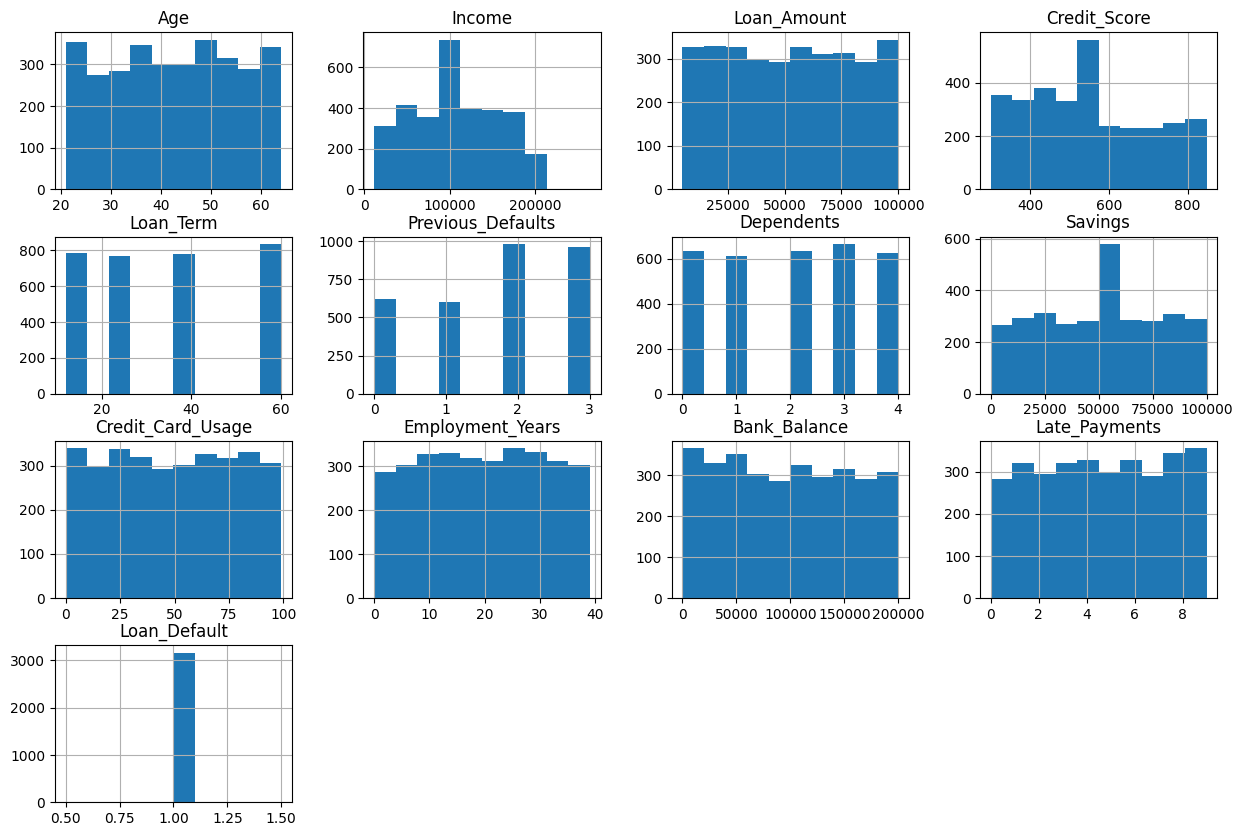

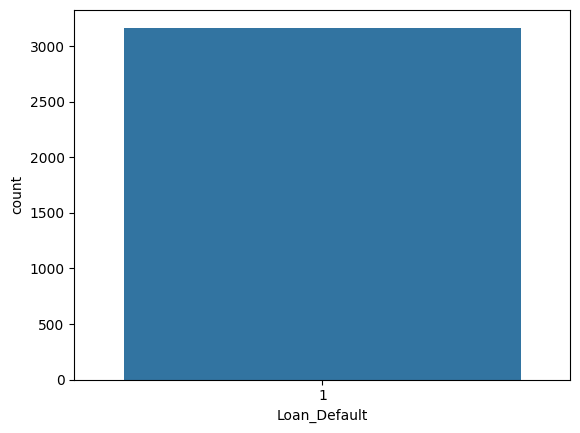

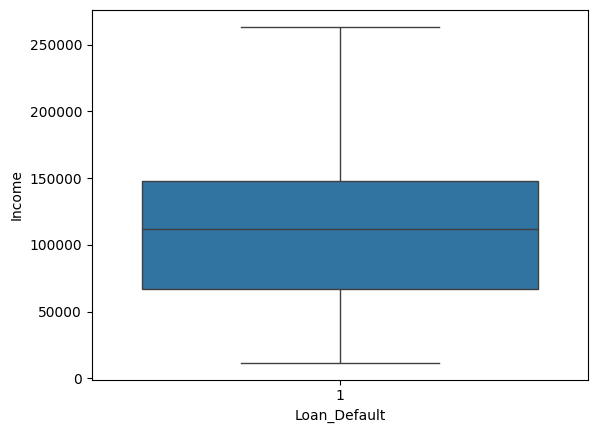

In [24]:
df.hist(figsize=(15,10))
plt.show()

sns.countplot(x="Loan_Default", data=df)
plt.show()

sns.boxplot(x="Loan_Default", y="Income", data=df)
plt.show()



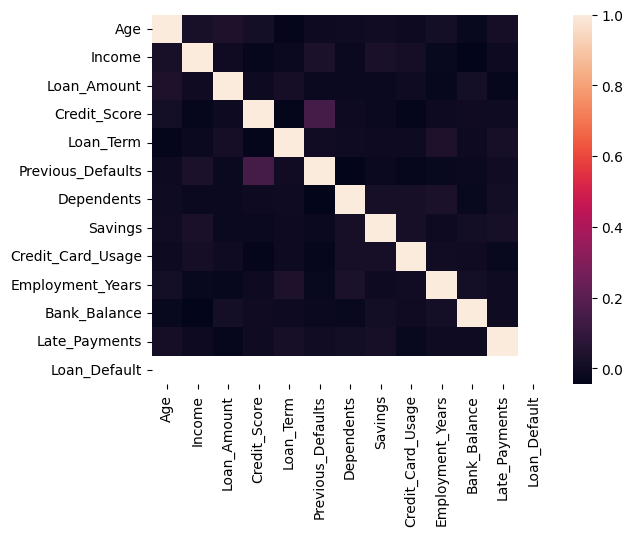

In [25]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=False)
plt.show()

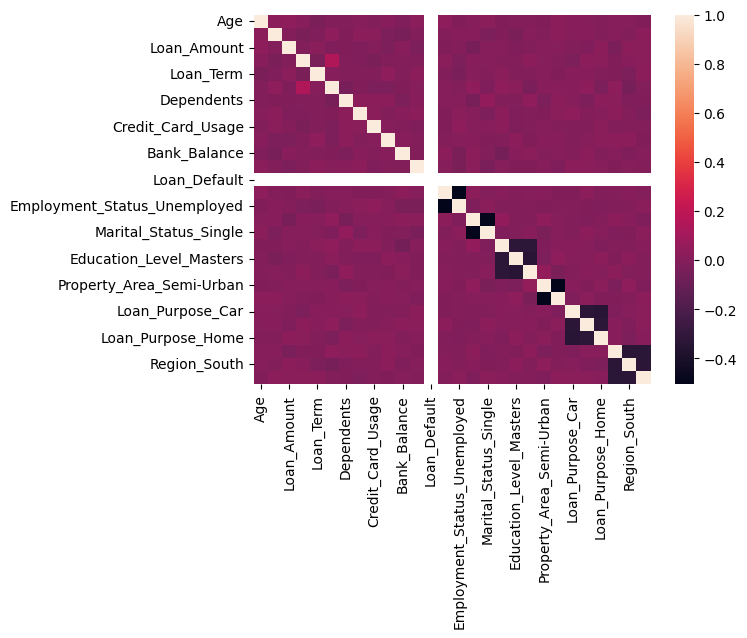

In [26]:
df = pd.get_dummies(df, drop_first=True)

sns.heatmap(df.corr(), annot=False)
plt.show()

i. Convert Categorical → Numerical

In [27]:
df = pd.get_dummies(df, drop_first=True)

Converted categorical data into numerical form so ML model can understand it.

**STEP 6: MODEL BUILDING**

a. Define X and y

In [28]:
X = df.drop("Loan_Default", axis=1)
y = df["Loan_Default"]

Separated input features (X) and target variable (y).

b. Train-Test Split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

 Split data into training and testing sets to evaluate model performance on unseen data.

c. Initialize Model

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

Selected Logistic Regression because this is a binary classification problem.

d. Convert to DataFrame

In [31]:

X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

In [32]:
print(df["Loan_Default"].value_counts())

Loan_Default
1    3166
Name: count, dtype: int64


In [33]:
from sklearn.model_selection import train_test_split

X = df.drop("Loan_Default", axis=1)
y = df["Loan_Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

In [34]:
cols = ["Income", "Loan_Amount", "Credit_Score"]

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [35]:
y.value_counts()

,count
Loan_Default,
1,3166


In [36]:
df["Loan_Default"] = (
    (df["Credit_Score"] < 600) |
    (df["Income"] < 50000) |
    (df["Previous_Defaults"] > 1)
).astype(int)

In [37]:
print("y_train:\n", y_train.value_counts())
print("y_test:\n", y_test.value_counts())

y_train:
 Loan_Default
1    2532
Name: count, dtype: int64
y_test:
 Loan_Default
1    634
Name: count, dtype: int64


In [38]:
for col in numerical_columns:
    if col != "Loan_Default":
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]

In [39]:
df["Loan_Default"] = (
    (df["Credit_Score"] < 600) |
    (df["Income"] < 50000) |
    (df["Previous_Defaults"] > 1)
).astype(int)

In [40]:
df["Loan_Default"].value_counts()

,count
Loan_Default,
1,2925
0,241


In [41]:
from sklearn.model_selection import train_test_split

X = df.drop("Loan_Default", axis=1)
y = df["Loan_Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000)

In [44]:

model.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

f. Prediction

In [45]:
y_pred = model.predict(X_test)

Generated predictions using the trained model

g. Evaluation

In [46]:

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Confusion Matrix:
 [[ 35  13]
 [  9 577]]
Accuracy: 0.9652996845425867
Precision: 0.9779661016949153
Recall: 0.984641638225256


Evaluated model performance using:

Accuracy → overall correctness

Precision → correct positive predictions

Recall → ability to detect actual positives

Confusion Matrix → detailed performance